In [11]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


iris = load_iris(as_frame=True)

iris_df = iris.frame

df = pd.DataFrame(iris_df)

df.sample(5)




,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
17,5.1,3.5,1.4,0.3,0
22,4.6,3.6,1.0,0.2,0
116,6.5,3.0,5.5,1.8,2
33,5.5,4.2,1.4,0.2,0
134,6.1,2.6,5.6,1.4,2


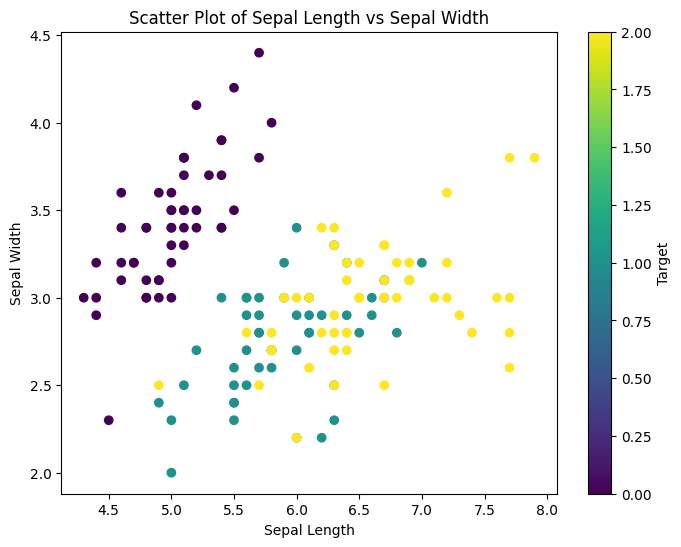

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

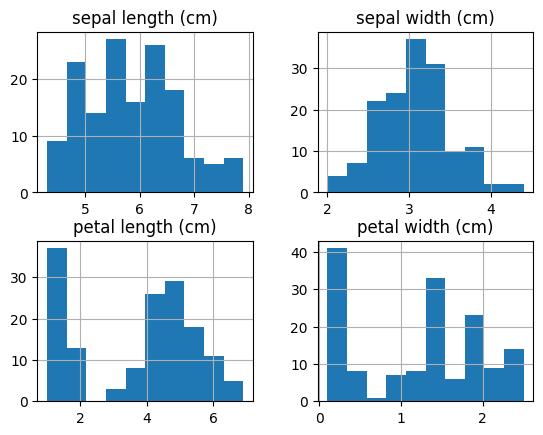

In [22]:
X = df.drop(columns=["target"])

y = df['target']

# Create a scatter plot of the first two features
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Scatter Plot of Sepal Length vs Sepal Width')
plt.colorbar(label='Target')
plt.show()



X.hist()


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, train_test_split

from sklearn.preprocessing import StandardScaler


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

X_train.shape, y_train.shape

((120, 4), (120,))

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_test = scaler.transform(X_test)

In [36]:
random_tree_model = RandomForestClassifier(random_state=17)

In [37]:
random_tree_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=17)

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix

print(mean_squared_error(y_train, random_tree_model.predict(X_train_scaled)))
print(mean_squared_error(y_test, random_tree_model.predict(X_train_test)))





0.0
0.03333333333333333


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 17,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
                                           
                                           
                                           
param_grid = {
    "n_estimators": list(range(10, 300, 10)),
    "max_depth": list(range(1, 20)),
    "min_samples_split": list(range(2, 20)),
    
}


grid_search_model = GridSearchCV(
    estimator=random_tree_model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search_model.fit(X_train_scaled, y_train)

print(grid_search_model.best_params_)
print(grid_search_model.best_score_)
print(grid_search_model.best_estimator_)
print(grid_search_model.cv_results_)


Fitting 5 folds for each of 9918 candidates, totalling 49590 fits
